**Import Library & Load Data**

In [4]:
# TAHAP 1: PERSIAPAN DATA & IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Mengatur Seed agar hasil bisa direproduksi
np.random.seed(42)
tf.random.set_seed(42)

# Mengunduh data langsung dari URL publik
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Dataset berhasil dimuat!")
display(df.head(3))

Dataset berhasil dimuat!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


Eksplorasi Data (EDA)

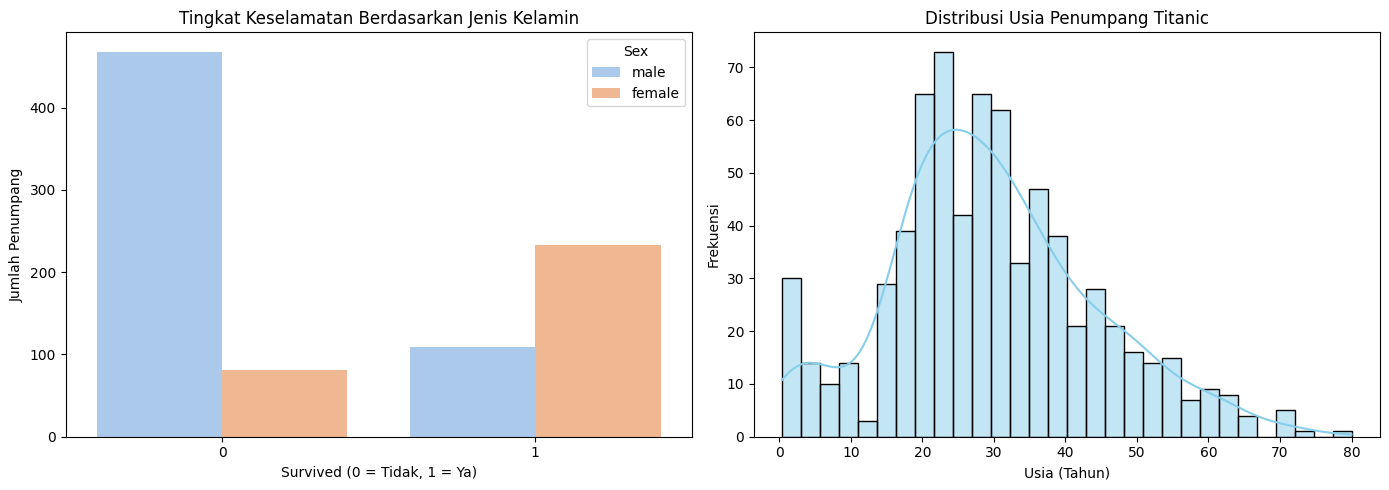

In [5]:
# TAHAP 2: EKSPLORASI DATA (EDA)

plt.figure(figsize=(14, 5))

# Visualisasi 1: Keselamatan berdasarkan Jenis Kelamin (Sex)
plt.subplot(1, 2, 1)
sns.countplot(x='Survived', hue='Sex', data=df, palette='pastel')
plt.title('Tingkat Keselamatan Berdasarkan Jenis Kelamin')
plt.xlabel('Survived (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Penumpang')

# Visualisasi 2: Distribusi Usia (Age)
plt.subplot(1, 2, 2)
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribusi Usia Penumpang Titanic')
plt.xlabel('Usia (Tahun)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

**Preprocessing & Feature Engineering**

In [6]:
# TAHAP 3: PREPROCESSING & FEATURE ENGINEERING

# 1. Ekstraksi Fitur 'Title' dari Nama (mewakili status sosial)
df['Title'] = df['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1))
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4}
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].map(title_mapping).fillna(5) # 5 untuk 'Rare'

# 2. Pembuatan Fitur Ukuran Keluarga
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 3. Imputasi (Pengisian) Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())           # Usia kosong diisi median
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Pelabuhan diisi modus
df['Fare'] = df['Fare'].fillna(df['Fare'].median())        # Harga tiket diisi median

# 4. Encoding Data Kategorikal menjadi Angka
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex']) # female: 0, male: 1
df['Embarked'] = le.fit_transform(df['Embarked'])

# 5. Drop kolom teks yang tidak relevan untuk pemodelan
features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=features_to_drop)

# 6. Train-Test Split (Pemisahan Data)
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Standardisasi (Scaling) -> Sangat penting untuk Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai! Dimensi data latih:", X_train_scaled.shape)

Preprocessing selesai! Dimensi data latih: (712, 9)


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_881/502830564.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1))


**Metode Konvensional**

In [7]:
# TAHAP 4: PELATIHAN MODEL KONVENSIONAL


# --- Model 1: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"=== RANDOM FOREST ===")
print(f"Akurasi       : {rf_acc * 100:.2f}%")
print(f"Waktu Training: {rf_train_time:.4f} detik\n")


# --- Model 2: XGBoost ---
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
start_time = time.time()
xgb_model.fit(X_train_scaled, y_train)
xgb_train_time = time.time() - start_time

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"=== XGBOOST ===")
print(f"Akurasi       : {xgb_acc * 100:.2f}%")
print(f"Waktu Training: {xgb_train_time:.4f} detik")

=== RANDOM FOREST ===
Akurasi       : 82.12%
Waktu Training: 0.3260 detik

=== XGBOOST ===
Akurasi       : 82.12%
Waktu Training: 0.0782 detik


**Model Deep Learning (MLP)**

menggunakan Multi-Layer Perceptron (MLP).

In [8]:
# TAHAP 5: PELATIHAN DEEP LEARNING (MLP)

# Membangun Arsitektur MLP
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3), # Mematikan 30% neuron agar tidak overfit

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid') # Output prediksi biner (0 atau 1)
])

# Compile model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping (menghentikan training jika val_loss tidak membaik setelah 10 epoch)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training Model
start_time = time.time()
history = mlp_model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=100,
                        batch_size=32,
                        callbacks=[early_stop],
                        verbose=0) # verbose 0 agar tampilan rapi
mlp_train_time = time.time() - start_time

# Evaluasi
mlp_loss, mlp_acc = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"=== DEEP LEARNING (MLP) ===")
print(f"Akurasi       : {mlp_acc * 100:.2f}%")
print(f"Waktu Training: {mlp_train_time:.4f} detik")
print("===========================\n")

# Menampilkan jumlah parameter
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== DEEP LEARNING (MLP) ===
Akurasi       : 82.12%
Waktu Training: 13.8494 detik



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,029 (35.27 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 5,892 (23.02 KB)